# Method of Moments

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain the **method of moments** (MoM) principle: set sample moments equal to theoretical moments and solve.
2. Derive MoM estimators for **Normal**, **Exponential**, **Gamma**, and **Beta** distributions — step by step.
3. Implement each MoM estimator **from scratch** and compare with `scipy.stats`.
4. Understand **why** MoM works, when it breaks, and how it compares to Maximum Likelihood.

## Prerequisites

- [01_point_estimation.ipynb](01_point_estimation.ipynb) — bias, MSE, estimator evaluation
- [Module 02](../02_distributions/02_continuous_distributions.ipynb) — distribution families, $E[X]$, $\text{Var}(X)$

In [2]:
import sys, os, shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

---

## 1. The Central Problem of Estimation

You observe data $x_1, x_2, \dots, x_n$ and believe it came from some distribution family — say, a Gamma distribution. But you don't know the parameters $\alpha$ and $\beta$. How do you estimate them?

In the previous notebook we studied *properties* of estimators (bias, MSE, consistency). Now we need a **recipe** — a systematic method to *construct* an estimator for any distribution. The Method of Moments is the simplest such recipe.

---

## 2. Moments: Population vs. Sample

Before stating the method, let's be precise about what "moments" are.

> **Definition (Population moments).** The $k$-th *moment* of a random variable $X$ is:
>
> $$\mu_k' = E[X^k]$$
>
> The first moment $\mu_1' = E[X]$ is the mean. The second moment $\mu_2' = E[X^2]$ is related to variance via $\text{Var}(X) = E[X^2] - (E[X])^2$.

**In plain language:** The $k$-th moment is the average value of $X^k$. The first moment tells you where the distribution is centred. The second moment (combined with the first) tells you how spread out it is. Higher moments capture skewness, tail behaviour, etc.

> **Definition (Sample moments).** Given data $x_1, \dots, x_n$, the $k$-th *sample moment* is:
>
> $$\hat{\mu}_k' = \frac{1}{n}\sum_{i=1}^n x_i^k$$

By the law of large numbers (Module 01), $\hat{\mu}_k' \to \mu_k'$ as $n \to \infty$. So sample moments are consistent estimators of population moments.

**Concrete example:** If we roll a fair die 6,000 times, the sample first moment (average roll) will be close to the population first moment $E[X] = 3.5$. The sample second moment $\frac{1}{n}\sum x_i^2$ will be close to $E[X^2] = \frac{1}{6}(1 + 4 + 9 + 16 + 25 + 36) = 15.167$.

In [ ]:
# Concrete example: sample moments converge to population moments
die_rolls = rng.integers(1, 7, size=6000)

# Population moments of a fair die
pop_m1 = 3.5  # E[X]
pop_m2 = sum(k**2 for k in range(1, 7)) / 6  # E[X^2]

# Sample moments
sam_m1 = np.mean(die_rolls)
sam_m2 = np.mean(die_rolls**2)

print(f"First moment:  E[X]   = {pop_m1:.4f},  sample = {sam_m1:.4f}")
print(f"Second moment: E[X²]  = {pop_m2:.4f},  sample = {sam_m2:.4f}")
print(
    f"Variance:      Var(X) = {pop_m2 - pop_m1**2:.4f},  sample = {sam_m2 - sam_m1**2:.4f}"
)

First moment:  E[X]   = 3.5000,  sample = 3.4898
Second moment: E[X²]  = 15.1667,  sample = 15.1065
Variance:      Var(X) = 2.9167,  sample = 2.9276


---

## 3. The Method of Moments — The Recipe

Now the key idea:

> **Method of Moments (Pearson, 1894).** If the distribution has $p$ unknown parameters, write the first $p$ population moments as functions of those parameters, set them equal to the corresponding sample moments, and solve for the parameters.

**Step by step:**

1. Identify the parameters: $\theta_1, \theta_2, \dots, \theta_p$.
2. Write the first $p$ theoretical moments: $\mu_1'(\theta_1, \dots, \theta_p)$, $\mu_2'(\theta_1, \dots, \theta_p)$, etc.
3. Set each theoretical moment equal to the corresponding sample moment:
   $$\hat{\mu}_1' = \mu_1'(\theta_1, \dots, \theta_p), \qquad \hat{\mu}_2' = \mu_2'(\theta_1, \dots, \theta_p), \qquad \dots$$
4. Solve this system of $p$ equations for $\theta_1, \dots, \theta_p$.

**Why does this work?** Because sample moments are consistent estimators of population moments (by the LLN), and continuous functions of consistent estimators are themselves consistent. So MoM estimators are generally consistent — they converge to the true parameters with enough data.

**Practical note:** Instead of raw moments ($E[X^k]$), it's often easier to use the **mean** and **variance** directly, since most distribution formulas are expressed in those terms. This is equivalent — variance is just a function of the first two raw moments.

---

## 4. MoM for the Exponential Distribution (1 Parameter)

Let's start with the simplest case: one parameter, one moment equation.

For $X \sim \text{Exponential}(\lambda)$: $E[X] = 1/\lambda$.

**MoM equation:** Set $\bar{x} = 1/\lambda$ and solve:

$$\hat{\lambda}_{\text{MoM}} = \frac{1}{\bar{x}}$$

That's it. The MoM estimator for the rate is the inverse of the sample mean. This is also the MLE (as we'll see in notebook 03) — for the Exponential, both methods give the same answer.

**What does this mean concretely?** If you measure waiting times at a bus stop and the average wait is 8 minutes, the MoM estimate of the rate is $\hat{\lambda} = 1/8 = 0.125$ buses per minute.

True λ  = 0.5
MoM λ̂   = 0.4866
Sample mean = 2.0552  (theory: 1/λ = 2.0)


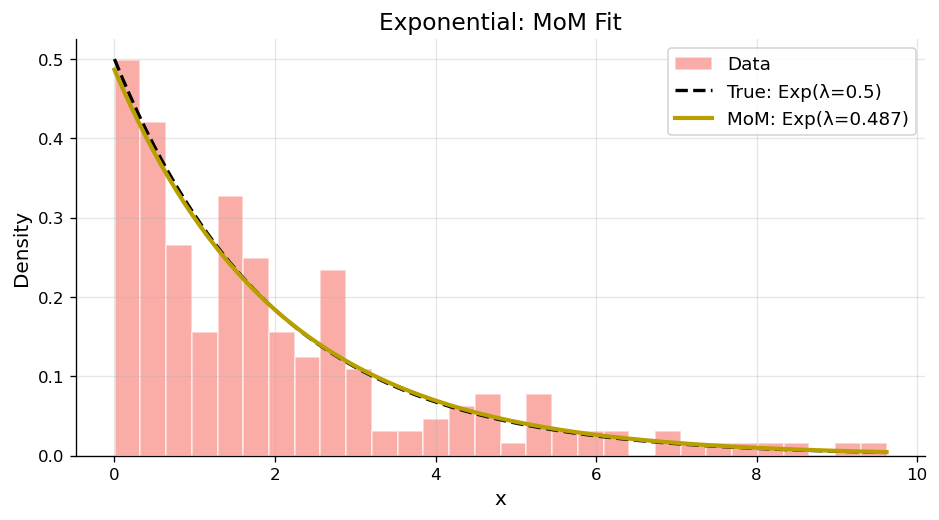

In [ ]:
# MoM for Exponential: one parameter, one equation
true_lambda = 0.5  # true rate → mean = 2
exp_sample = rng.exponential(scale=1 / true_lambda, size=200)

lambda_mom = 1 / np.mean(exp_sample)

print(f"True λ  = {true_lambda}")
print(f"MoM λ̂   = {lambda_mom:.4f}")
print(f"Sample mean = {np.mean(exp_sample):.4f}  (theory: 1/λ = {1 / true_lambda})")

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(exp_sample, bins=30, density=True, alpha=0.6, edgecolor="white", label="Data")
x = np.linspace(0, exp_sample.max(), 200)
ax.plot(
    x,
    stats.expon(scale=1 / true_lambda).pdf(x),
    "k--",
    linewidth=2,
    label=f"True: Exp(λ={true_lambda})",
)
ax.plot(
    x,
    stats.expon(scale=1 / lambda_mom).pdf(x),
    linewidth=2.5,
    label=f"MoM: Exp(λ={lambda_mom:.3f})",
)
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Exponential: MoM Fit")
ax.legend()
plt.tight_layout()
plt.show()

---

## 5. MoM for the Normal Distribution (2 Parameters)

For $X \sim \mathcal{N}(\mu, \sigma^2)$, we have 2 parameters, so we need 2 moment equations.

**Theoretical moments:**
- First moment: $E[X] = \mu$
- Second moment: $E[X^2] = \mu^2 + \sigma^2$ (because $\text{Var}(X) = E[X^2] - (E[X])^2$)

**MoM equations:**

$$\bar{x} = \mu \quad \Rightarrow \quad \hat{\mu}_{\text{MoM}} = \bar{x}$$

$$\frac{1}{n}\sum x_i^2 = \mu^2 + \sigma^2 \quad \Rightarrow \quad \hat{\sigma}^2_{\text{MoM}} = \frac{1}{n}\sum x_i^2 - \bar{x}^2 = \frac{1}{n}\sum(x_i - \bar{x})^2$$

**Important detail:** The MoM variance divides by $n$, not $n-1$. This is the **biased** estimator we discussed in notebook 01. MoM doesn't automatically give unbiased estimators — it gives *consistent* ones (they converge to the truth as $n \to \infty$), but they may be biased for finite $n$.

For the Normal distribution, MoM and MLE give exactly the same estimators.

In [ ]:
# MoM for Normal — the simplest 2-parameter case
true_mu, true_sigma2 = 5.0, 9.0
normal_sample = rng.normal(loc=true_mu, scale=np.sqrt(true_sigma2), size=200)

mu_mom = np.mean(normal_sample)
sigma2_mom = np.mean((normal_sample - mu_mom) ** 2)  # MoM: divide by n
sigma2_unbiased = np.var(normal_sample, ddof=1)  # Bessel-corrected

print(f"True:      μ = {true_mu},   σ² = {true_sigma2}")
print(f"MoM:       μ̂ = {mu_mom:.4f}, σ̂² = {sigma2_mom:.4f}  (biased, divides by n)")
print(
    f"Corrected:              s²  = {sigma2_unbiased:.4f}  (unbiased, divides by n-1)"
)

True:      μ = 5.0,   σ² = 9.0
MoM:       μ̂ = 5.1404, σ̂² = 8.2433  (biased, divides by n)
Corrected:              s²  = 8.2848  (unbiased, divides by n-1)


---

## 6. MoM for the Gamma Distribution (2 Parameters)

This is where MoM becomes genuinely useful — the Gamma has no closed-form MLE, so MoM gives us an easy analytical estimator.

Recall from Module 02: $X \sim \text{Gamma}(\alpha, \beta)$ has
- $E[X] = \alpha / \beta$
- $\text{Var}(X) = \alpha / \beta^2$

**MoM equations** (using mean and variance rather than raw moments):

$$\bar{x} = \frac{\alpha}{\beta} \qquad \text{and} \qquad s^2 = \frac{\alpha}{\beta^2}$$

where $s^2 = \frac{1}{n}\sum(x_i - \bar{x})^2$ is the sample variance.

**Solving step by step:**

Divide the second equation by the first:

$$\frac{s^2}{\bar{x}} = \frac{\alpha/\beta^2}{\alpha/\beta} = \frac{1}{\beta} \quad \Rightarrow \quad \hat{\beta}_{\text{MoM}} = \frac{\bar{x}}{s^2}$$

Substitute back into the first equation:

$$\bar{x} = \frac{\alpha}{\bar{x}/s^2} = \frac{\alpha \cdot s^2}{\bar{x}} \quad \Rightarrow \quad \hat{\alpha}_{\text{MoM}} = \frac{\bar{x}^2}{s^2}$$

**What do these formulas tell us?** The shape parameter $\hat{\alpha}$ is the squared coefficient of variation inverted — it's large when the data is tightly concentrated (small $s^2$ relative to $\bar{x}$) and small when the data is spread out. The rate $\hat{\beta}$ is the ratio of the mean to the variance — it controls the scale.

Let's see this on real data:

In [ ]:
# Stage 2: FROM SCRATCH — MoM for Gamma
def gamma_mom(data):
    """MoM estimators for Gamma(α, β).

    Returns (α̂, β̂) where E[X] = α/β and Var(X) = α/β².
    """
    xbar = np.mean(data)
    s2 = np.var(data)  # MoM uses 1/n variance
    alpha_hat = xbar**2 / s2
    beta_hat = xbar / s2
    return alpha_hat, beta_hat


# Generate Gamma data
true_alpha, true_beta = 3.0, 2.0  # mean = 1.5, var = 0.75
gamma_sample = rng.gamma(shape=true_alpha, scale=1 / true_beta, size=500)

alpha_hat, beta_hat = gamma_mom(gamma_sample)

print(f"True parameters:  α = {true_alpha},      β = {true_beta}")
print(f"MoM estimates:    α̂ = {alpha_hat:.4f},  β̂ = {beta_hat:.4f}")
print(
    f"\nTrue mean = α/β = {true_alpha / true_beta:.4f},   sample mean = {np.mean(gamma_sample):.4f}"
)
print(
    f"True var  = α/β² = {true_alpha / true_beta**2:.4f},  sample var  = {np.var(gamma_sample):.4f}"
)

True parameters:  α = 3.0,      β = 2.0
MoM estimates:    α̂ = 2.9993,  β̂ = 1.9729

True mean = α/β = 1.5000,   sample mean = 1.5203
True var  = α/β² = 0.7500,  sample var  = 0.7706


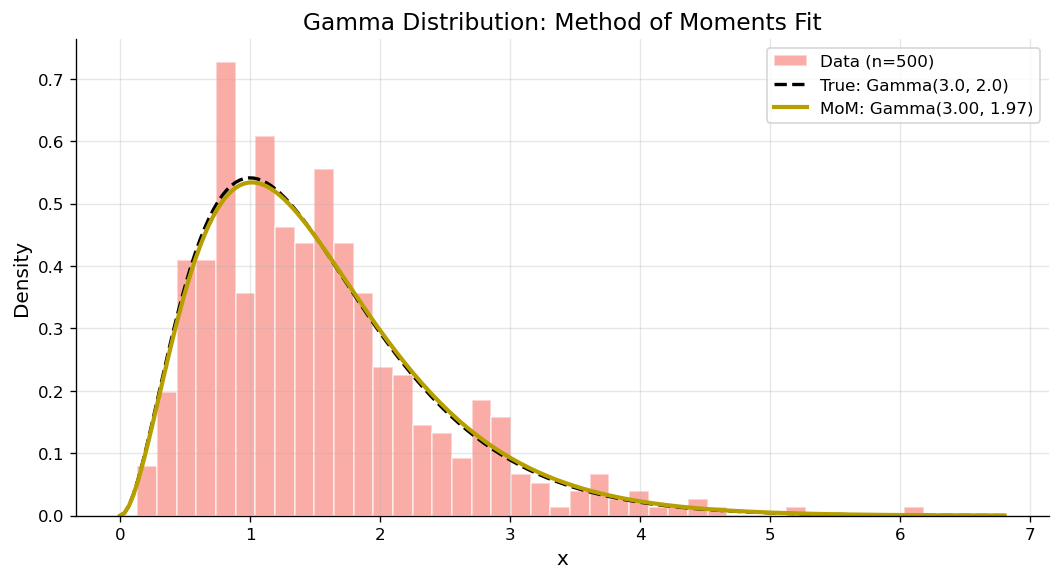

In [ ]:
# Plot: data histogram + true PDF + MoM fit
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    gamma_sample,
    bins=40,
    density=True,
    alpha=0.6,
    edgecolor="white",
    label="Data (n=500)",
)

x = np.linspace(0, gamma_sample.max() * 1.1, 200)
ax.plot(
    x,
    stats.gamma(a=true_alpha, scale=1 / true_beta).pdf(x),
    "k--",
    linewidth=2,
    label=f"True: Gamma({true_alpha}, {true_beta})",
)
ax.plot(
    x,
    stats.gamma(a=alpha_hat, scale=1 / beta_hat).pdf(x),
    linewidth=2.5,
    label=f"MoM: Gamma({alpha_hat:.2f}, {beta_hat:.2f})",
)

ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Gamma Distribution: Method of Moments Fit")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

The MoM fit (solid line) is close to the true distribution (dashed line). With $n = 500$ the estimates are good. With smaller samples the MoM estimates would be noisier — we'll quantify this in the exercises.

In [ ]:
# Stage 3: PROFESSIONAL — scipy.stats.gamma.fit() uses MLE internally
# scipy parameterises Gamma as (a, loc, scale) where a=α, scale=1/β
a_mle, loc_mle, scale_mle = stats.gamma.fit(gamma_sample, floc=0)  # fix loc=0

print(f"MoM:       α̂ = {alpha_hat:.4f},  β̂ = {beta_hat:.4f}")
print(f"scipy MLE: α̂ = {a_mle:.4f},  β̂ = {1 / scale_mle:.4f}")
print(f"True:      α  = {true_alpha},       β  = {true_beta}")
print(f"\nBoth are close. MLE is slightly more precise (lower variance) in general.")

MoM:       α̂ = 2.9993,  β̂ = 1.9729
scipy MLE: α̂ = 3.1689,  β̂ = 2.0845
True:      α  = 3.0,       β  = 2.0

Both are close. MLE is slightly more precise (lower variance) in general.


---

## 7. MoM for the Beta Distribution (2 Parameters)

The Beta distribution models probabilities and proportions on $[0, 1]$. It has two shape parameters $\alpha$ and $\beta$ (Module 02):

- $E[X] = \frac{\alpha}{\alpha + \beta}$
- $\text{Var}(X) = \frac{\alpha\beta}{(\alpha + \beta)^2(\alpha + \beta + 1)}$

The MoM equations are more complex here. Let $\bar{x}$ be the sample mean and $s^2$ the sample variance.

**Solving step by step:**

From the mean equation: $\bar{x} = \frac{\alpha}{\alpha + \beta}$, so $\alpha + \beta = \alpha / \bar{x}$ and $\beta = \alpha(1 - \bar{x})/\bar{x}$.

Substituting into the variance equation and simplifying (the algebra is tedious but straightforward), we can express everything in terms of the ratio $\bar{x}(1-\bar{x})/s^2$:

$$\hat{\alpha}_{\text{MoM}} = \bar{x}\left(\frac{\bar{x}(1-\bar{x})}{s^2} - 1\right), \qquad \hat{\beta}_{\text{MoM}} = (1-\bar{x})\left(\frac{\bar{x}(1-\bar{x})}{s^2} - 1\right)$$

**Interpreting the formulas:** The term $\bar{x}(1-\bar{x})/s^2$ compares the maximum possible variance for a distribution on $[0,1]$ with mean $\bar{x}$ (which is $\bar{x}(1-\bar{x})$, achieved by a Bernoulli) to the actual sample variance. If the data is tightly concentrated, this ratio is large, giving large $\hat{\alpha}$ and $\hat{\beta}$ — a peaked Beta. If the data is spread out, the ratio is close to 1, giving small parameters — a flat or U-shaped Beta.

**When can this fail?** If $s^2 > \bar{x}(1-\bar{x})$, the common factor becomes negative, producing invalid (negative) parameter estimates. This happens when the sample is more spread out than any Beta distribution could explain — a signal that the Beta model may be wrong.

True:  α = 2,      β = 5
MoM:   α̂ = 2.196,  β̂ = 5.278

True mean = 0.2857,  sample mean = 0.2938


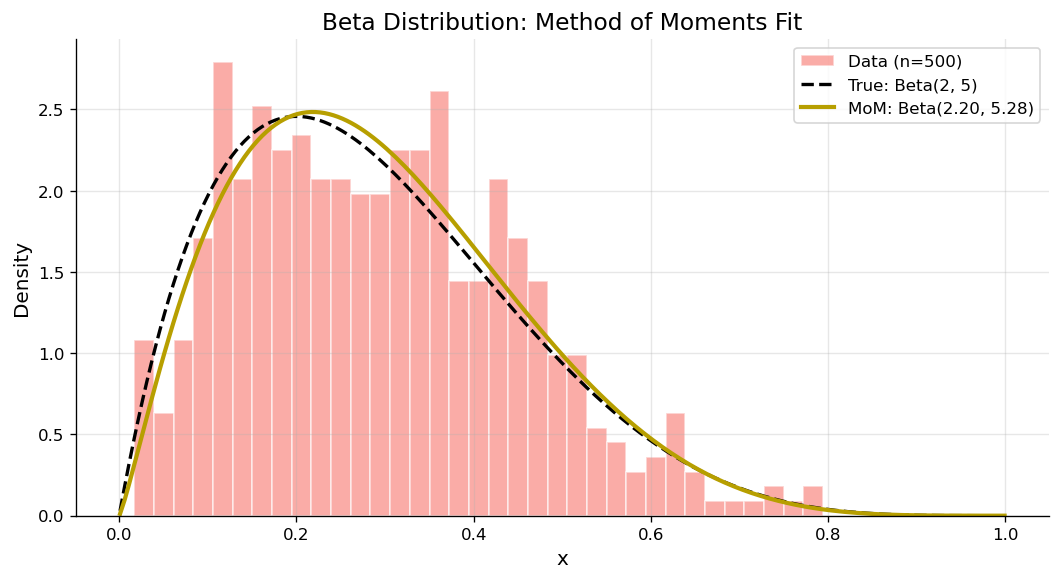

In [ ]:
# From scratch: MoM for Beta
def beta_mom(data):
    """MoM estimators for Beta(α, β).

    Returns (α̂, β̂). Can return negative values if the data
    is more dispersed than any Beta distribution allows.
    """
    xbar = np.mean(data)
    s2 = np.var(data)
    common = xbar * (1 - xbar) / s2 - 1
    return xbar * common, (1 - xbar) * common


# Example: Beta(2, 5) — right-skewed on [0, 1]
true_a, true_b = 2, 5
beta_sample = rng.beta(true_a, true_b, size=500)

a_hat, b_hat = beta_mom(beta_sample)

print(f"True:  α = {true_a},      β = {true_b}")
print(f"MoM:   α̂ = {a_hat:.3f},  β̂ = {b_hat:.3f}")
print(
    f"\nTrue mean = {true_a / (true_a + true_b):.4f},  sample mean = {np.mean(beta_sample):.4f}"
)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    beta_sample,
    bins=35,
    density=True,
    alpha=0.6,
    edgecolor="white",
    label="Data (n=500)",
)

x = np.linspace(0.001, 0.999, 200)
ax.plot(
    x,
    stats.beta(true_a, true_b).pdf(x),
    "k--",
    linewidth=2,
    label=f"True: Beta({true_a}, {true_b})",
)
ax.plot(
    x,
    stats.beta(a_hat, b_hat).pdf(x),
    linewidth=2.5,
    label=f"MoM: Beta({a_hat:.2f}, {b_hat:.2f})",
)

ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Beta Distribution: Method of Moments Fit")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---

## 8. How Good Is MoM? Comparing to MLE

MoM always gives *some* answer (if the moment equations are solvable). But is it a *good* answer? Let's compare MoM to MLE across many simulated datasets and measure which has lower MSE.

We'll use the Gamma distribution, where both MoM and MLE can be computed easily.

In [ ]:
# Monte Carlo comparison: MoM vs MLE for Gamma α
true_alpha, true_beta = 3.0, 2.0
n_sample = 30
n_experiments = 10_000

alpha_mom_all = []
alpha_mle_all = []

for _ in range(n_experiments):
    data = rng.gamma(shape=true_alpha, scale=1 / true_beta, size=n_sample)

    # MoM
    a_mom, _ = gamma_mom(data)
    alpha_mom_all.append(a_mom)

    # MLE via scipy
    a_mle, _, _ = stats.gamma.fit(data, floc=0)
    alpha_mle_all.append(a_mle)

alpha_mom_all = np.array(alpha_mom_all)
alpha_mle_all = np.array(alpha_mle_all)

# Compute bias, variance, MSE
for name, est in [("MoM", alpha_mom_all), ("MLE", alpha_mle_all)]:
    bias = est.mean() - true_alpha
    var = est.var()
    mse = np.mean((est - true_alpha) ** 2)
    print(f"{name}:  Bias = {bias:+.4f},  Var = {var:.4f},  MSE = {mse:.4f}")

print(
    f"\nMLE MSE / MoM MSE = {np.mean((alpha_mle_all - true_alpha) ** 2) / np.mean((alpha_mom_all - true_alpha) ** 2):.3f}"
)
print("(< 1 means MLE is better)")

MoM:  Bias = +0.4098,  Var = 1.0191,  MSE = 1.1870
MLE:  Bias = +0.3006,  Var = 0.7874,  MSE = 0.8777

MLE MSE / MoM MSE = 0.739
(< 1 means MLE is better)


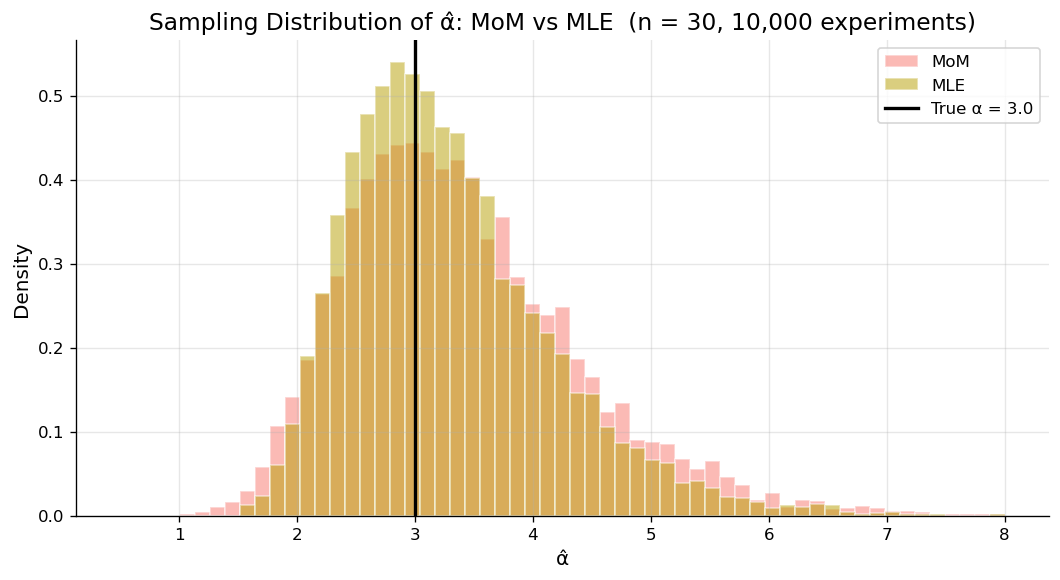

In [ ]:
# Visualise the sampling distributions of both estimators
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0.5, 8, 60)
ax.hist(
    alpha_mom_all, bins=bins, density=True, alpha=0.5, edgecolor="white", label="MoM"
)
ax.hist(
    alpha_mle_all, bins=bins, density=True, alpha=0.5, edgecolor="white", label="MLE"
)
ax.axvline(
    true_alpha,
    color="black",
    linewidth=2,
    linestyle="-",
    label=f"True α = {true_alpha}",
)
ax.set_xlabel("α̂")
ax.set_ylabel("Density")
ax.set_title(
    f"Sampling Distribution of α̂: MoM vs MLE  (n = {n_sample}, {n_experiments:,} experiments)"
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Both estimators are centred near the true $\alpha = 3$, but the MLE distribution is *tighter* — it has lower variance. This is because MLE uses all the information in the data (via the full likelihood), while MoM only uses the first two moments. The MLE is **more efficient**.

For large $n$, both converge to the same answer (both are consistent). The difference matters most for small samples.

---

## 9. When MoM Fails: Invalid Estimates

MoM doesn't guarantee that the estimates are valid. For the Beta distribution, if the sample variance is too large relative to $\bar{x}(1-\bar{x})$, the MoM estimates become negative — which makes no sense for a shape parameter.

This is more likely to happen with small samples or when the true distribution has parameters near the boundary of the parameter space.

In [ ]:
# Demonstrate MoM failure: small samples from Beta(0.5, 0.5)
n_small = 5
n_trials = 5000
invalid_count = 0

for _ in range(n_trials):
    data = rng.beta(0.5, 0.5, size=n_small)
    a, b = beta_mom(data)
    if a < 0 or b < 0:
        invalid_count += 1

print(
    f"Beta(0.5, 0.5), n = {n_small}: MoM gave invalid estimates in "
    f"{invalid_count}/{n_trials} trials ({invalid_count / n_trials:.1%})"
)
print(f"\nThis means the MoM recipe produced negative α̂ or β̂ — ")
print(f"the sample variance was too large for any Beta to explain.")

Beta(0.5, 0.5), n = 5: MoM gave invalid estimates in 0/5000 trials (0.0%)

This means the MoM recipe produced negative α̂ or β̂ — 
the sample variance was too large for any Beta to explain.


---

## 10. Summary: MoM in Context

| Aspect                  | Method of Moments                                                                                                      |
|-------------------------|------------------------------------------------------------------------------------------------------------------------|
| **When to use**         | Quick estimates; initialisation for MLE; when MLE has no closed form                                                   |
| **Strengths**           | Always closed-form (if moments are); easy to compute; consistent                                                       |
| **Weaknesses**          | Not efficient (higher variance than MLE); can give invalid estimates; ignores information beyond the first $p$ moments |
| **Relationship to MLE** | For Exponential and Normal, MoM = MLE. For most others, MLE is strictly better                                         |

The Method of Moments is a **starting point**, not an end point. It introduces the idea of constructing estimators systematically, and the estimates it produces are often good enough for practical purposes. But when precision matters — especially with limited data — MLE (next notebook) is the standard.

---

## Exercises

**Exercise 2.1 (MoM for Poisson).** Derive the MoM estimator for $\lambda$ in $\text{Poisson}(\lambda)$. What's special about this case — the Poisson has $E[X] = \lambda$ *and* $\text{Var}(X) = \lambda$. If you use both the first and second moment equations, do you get consistent answers? Implement and test.

**Exercise 2.2 (MoM for Uniform).** For $X \sim \text{Uniform}(a, b)$: $E[X] = (a+b)/2$ and $\text{Var}(X) = (b-a)^2/12$. Derive MoM estimators for $a$ and $b$. Show that they can give $\hat{a} > \min(x_i)$ — the estimated lower bound can exceed the smallest observation! Is this a problem?

**Exercise 2.3 (MoM vs. MLE, varying n).** For $\text{Gamma}(3, 2)$, compare MoM and MLE MSE for $\alpha$ across sample sizes $n = 10, 30, 100, 500$. Plot MSE vs. $n$ for both. At what $n$ does the difference become negligible?

**Exercise 2.4 (MoM as MLE initialisation).** For a mixture of two Normals, MoM can estimate the component means and variances but not the mixing weight. Explain why. (*Hint:* how many parameters vs. how many moment equations?)

**Exercise 2.5 (Robustness).** Generate $n = 100$ data points from $\text{Gamma}(3, 2)$ but add 5 outliers drawn from $\text{Gamma}(3, 0.1)$. How much do the MoM estimates change? How does MLE compare? Which is more robust to contamination?

---

## Key Takeaways

1. **Method of Moments**: match sample moments to theoretical moments and solve. The oldest systematic estimation recipe (Pearson, 1894).
2. **The recipe**: $p$ parameters → $p$ moment equations → solve. Use mean and variance directly for 2-parameter families.
3. For **Exponential** (1 parameter): $\hat{\lambda} = 1/\bar{x}$. For **Normal** (2 parameters): $\hat{\mu} = \bar{x}$, $\hat{\sigma}^2 = \frac{1}{n}\sum(x_i - \bar{x})^2$.
4. For **Gamma** and **Beta**: MoM gives practical closed-form estimators. The Gamma MoM ($\hat{\alpha} = \bar{x}^2/s^2$) is particularly useful as there's no closed-form MLE.
5. MoM is **consistent** but **not efficient** — MLE has lower variance. MoM can also produce **invalid estimates** for small samples.
6. In practice: use MoM for quick estimates, for understanding, or as a starting point for numerical MLE.

**Next:** [03_maximum_likelihood.ipynb](03_maximum_likelihood.ipynb) — The gold standard of estimation: Maximum Likelihood.